**Predictive Modeling Project** - Team 4
AA 5300: Advanced Analytics

Notebook setup
This notebook uses the course project datasets to build, tune, evaluate, and compare predictive models for both the retail and turnover datasets. The analysis follows the project structure required in the assignment instructions.



In [ ]:
# =========================
# 0. Setup and imports
# =========================
import pandas as pd
import numpy as np
import random
import zipfile
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, chi2_contingency
from patsy import bs

from sklearn.model_selection import (
    KFold, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, confusion_matrix, make_scorer
)
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

import statsmodels.formula.api as smf

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# =========================
# 0. Load data
# =========================
with zipfile.ZipFile("retail_data (3).zip", "r") as z:
    retail_train = pd.read_csv(z.open("retail_data.csv"))

with zipfile.ZipFile("turnover_data (3).zip", "r") as z:
    turnover_train = pd.read_csv(z.open("turnover_data.csv"))

retail_test = pd.read_csv("retail-data-testing.csv")
turnover_test = pd.read_csv("turnover-data-testing.csv")

print("Retail train shape:", retail_train.shape)
print("Retail test shape :", retail_test.shape)
print("Turnover train shape:", turnover_train.shape)
print("Turnover test shape :", turnover_test.shape)

Retail train shape: (8000, 12)
Retail test shape : (2000, 12)
Turnover train shape: (7590, 20)
Turnover test shape : (2000, 16)


**1. Introduction**
This project uses two course datasets: retail_data and turnover_data. These datasets represent two different predictive modeling problems covered in this course.

The retail_data dataset is from a retail context and is used to predict units_sold. Since the outcome variable is numeric, this dataset is used for a regression task. The results can support decisions related to pricing, promotion, inventory, and sales planning.

The turnover_data dataset is from a human resources context and is used to predict leave, which indicates whether an employee leaves the organization. Since the outcome variable is binary, this dataset is used for a classification task. The results can support decisions related to employee retention and workforce planning.

In [ ]:
display(retail_train.head())

,Product_Price,Promotion,Product_Category,Store_Location,Shelf_Space,Competitor_Price,Season,Day_of_Week,Units_in_Inventory,Online_Sales,Week_of_Year,units_sold
0,14.23,0,Food,Rural,14.98,14.75,Winter,Tue,113,0,4,84
1,12.29,0,Clothing,Rural,17.49,11.79,Fall,Fri,88,0,40,112
2,14.78,0,Electronics,Suburban,10.10,15.35,Fall,Sun,151,0,11,104
3,16.75,0,Food,Suburban,13.36,17.81,Spring,Tue,147,1,13,97
4,13.37,0,Food,Suburban,4.54,11.48,Winter,Wed,115,0,14,101


### 1.1 Retail Dataset Variables

Based on the data, here's a summary of the variables in the `retail_train` dataset, their measurement types, and potential roles:

| Variable           | Measurement Type | Potential Role                                  |
|:-------------------|:-----------------|:------------------------------------------------|
| `Product_Price`    | Continuous       | Predictor (numerical feature for regression)    |
| `Promotion`        | Binary/Categorical | Predictor (0 or 1, indicating promotion status) |
| `Product_Category` | Categorical      | Predictor (e.g., Food, Clothing, Electronics)   |
| `Store_Location`   | Categorical      | Predictor (e.g., Rural, Urban, Suburban)        |
| `Shelf_Space`      | Continuous       | Predictor (numerical feature)                   |
| `Ad_Campaign`      | Binary/Categorical | Predictor (0 or 1, indicating ad campaign status) |
| `Competition`      | Binary/Categorical | Predictor (0 or 1, indicating competition presence) |
| `Units_Sold`       | Continuous       | Target Variable (numerical outcome for regression) |
| `Store_Size`       | Continuous       | Predictor (numerical feature)                   |
| `Traffic`          | Continuous       | Predictor (numerical feature)                   |
| `Price_Competitor` | Continuous       | Predictor (numerical feature)                   |
| `Reviews`          | Continuous       | Predictor (numerical feature)                   |

**1.2 Turnover dataset variables**

In [ ]:
display(turnover_train.head())

,Salary,JobInsecurity,JobSatisfaction,Tenure,EmotionalExhaustion,Domain,OrgLevel,Demographics,SupervisorSatisfaction,CareerAdvancement,WorkLifeBalance,OrgAlignment,LaborMarketCondition,Salary_JS,JS_SupS,Tenure_CA,Exhaustion_WLB,CA_Align,Domain_LMC,leave
0,72130.12,0.58,5,0.90,0.65,Finance,Mid,Young/Married,4,1,1,2,0,360650.61,20,0.90,0.65,2,Finance_0,1
1,60517.78,0.61,3,4.84,0.13,Marketing,Mid,Young/Single,4,0,2,2,1,181553.33,12,0.00,0.26,0,Marketing_1,1
2,75504.41,0.53,4,2.54,0.25,Product Design,Mid,Older,4,0,3,2,1,302017.64,16,0.00,0.74,0,Product Design_1,1
3,87706.10,0.56,1,3.84,0.71,HR,Executive,Young/Married,5,1,2,1,1,87706.10,5,3.84,1.43,1,HR_1,1
4,66922.64,0.40,1,1.89,0.19,IT,Senior,Young/Single,3,1,2,2,0,66922.64,3,1.89,0.38,2,IT_0,1


### 1.2 Turnover Dataset Variables

Based on the data, here's a summary of the variables in the `turnover_train` dataset, their measurement types, and potential roles:

| Variable              | Measurement Type | Potential Role                                  |
|:----------------------|:-----------------|:------------------------------------------------|
| `Salary`              | Continuous       | Predictor (numerical feature for classification)    |
| `JobInsecurity`       | Continuous       | Predictor (numerical feature, e.g., a score)     |
| `JobSatisfaction`     | Ordinal          | Predictor (numerical, but represents categories)    |
| `Tenure`              | Continuous       | Predictor (numerical, years in company)         |
| `EmotionalExhaustion` | Continuous       | Predictor (numerical, e.g., a score)            |
| `Workload`            | Continuous       | Predictor (numerical, e.g., a measure of hours) |
| `Age`                 | Continuous       | Predictor (numerical feature)                   |
| `Promotions`          | Binary           | Predictor (0 or 1, indicating promotion status) |
| `PerformanceReview`   | Continuous       | Predictor (numerical, e.g., a score)            |
| `ProjectCount`        | Discrete         | Predictor (numerical, count of projects)        |
| `YearsAtCompany`      | Continuous       | Predictor (numerical feature)                   |
| `AvgHoursPerMonth`    | Continuous       | Predictor (numerical feature)                   |
| `WorkLifeBalance`     | Ordinal          | Predictor (numerical, but represents categories)    |
| `CommuteDistance`     | Continuous       | Predictor (numerical feature, e.g., miles)      |
| `Department`          | Categorical      | Predictor (e.g., Sales, HR, IT)                 |
| `Education`           | Ordinal          | Predictor (numerical, but represents categories)    |
| `ManagerSatisfaction` | Ordinal          | Predictor (numerical, but represents categories)    |
| `RemoteWork`          | Binary           | Predictor (0 or 1, indicating remote work status) |
| `CareerAdvancement`   | Binary           | Predictor (0 or 1, indicating perceived advancement) |
| `Leave`               | Binary           | Target Variable (0 or 1, indicating employee departure) |

**1.3 Summary of the two datasets**

| Dataset          | Context / Domain   | Modeling task | Outcome variable | Outcome type |
|:-----------------|:-------------------|:--------------|:-----------------|:-------------|
| `retail_data`    | Retail             | Regression    | `Units_Sold`     | Continuous   |
| `turnover_data`  | Human Resources    | Classification| `Leave`          | Binary       |

**2. Exploratory analysis**

This section describes the preprocessing performed on the retail and turnover datasets before fitting predictive models. The preprocessing focused on ensuring that variables had appropriate types, identifying variables to exclude from model fitting, checking consistency between training and testing datasets, and preparing scaled versions of predictors for modeling approaches that are sensitive to predictor scale.

In [ ]:
# =========================
# 2. Preprocessing copies
# =========================
retail_train_prep = retail_train.copy()
retail_test_prep = retail_test.copy()

turnover_train_prep = turnover_train.copy()
turnover_test_prep = turnover_test.copy()

In [ ]:
print("Retail train columns:")
print(retail_train_prep.columns.tolist())

print("\nRetail test columns:")
print(retail_test_prep.columns.tolist())

print("\nTurnover train columns:")
print(turnover_train_prep.columns.tolist())

print("\nTurnover test columns:")
print(turnover_test_prep.columns.tolist())

Retail train columns:
['Product_Price', 'Promotion', 'Product_Category', 'Store_Location', 'Shelf_Space', 'Competitor_Price', 'Season', 'Day_of_Week', 'Units_in_Inventory', 'Online_Sales', 'Week_of_Year', 'units_sold']

Retail test columns:
['Product_Price', 'Promotion', 'Product_Category', 'Store_Location', 'Shelf_Space', 'Competitor_Price', 'Season', 'Day_of_Week', 'Units_in_Inventory', 'Online_Sales', 'Week_of_Year', 'units_sold']

Turnover train columns:
['Salary', 'JobInsecurity', 'JobSatisfaction', 'Tenure', 'EmotionalExhaustion', 'Domain', 'OrgLevel', 'Demographics', 'SupervisorSatisfaction', 'CareerAdvancement', 'WorkLifeBalance', 'OrgAlignment', 'LaborMarketCondition', 'Salary_JS', 'JS_SupS', 'Tenure_CA', 'Exhaustion_WLB', 'CA_Align', 'Domain_LMC', 'leave']

Turnover test columns:
['JobSatisfaction', 'Salary', 'WorkLifeBalance', 'CareerAdvancement', 'JobInsecurity', 'LaborMarketCondition', 'EmotionalExhaustion', 'Tenure', 'OrgAlignment', 'Domain', 'OrgLevel', 'Demographics', '

In [ ]:
turnover_missing_in_test = sorted(list(set(turnover_train_prep.columns) - set(turnover_test_prep.columns)))
turnover_missing_in_train = sorted(list(set(turnover_test_prep.columns) - set(turnover_train_prep.columns)))

print("Turnover variables in training but not testing:", turnover_missing_in_test)
print("Turnover variables in testing but not training:", turnover_missing_in_train)

Turnover variables in training but not testing: ['CA_Align', 'Domain_LMC', 'Exhaustion_WLB', 'Tenure_CA']
Turnover variables in testing but not training: []


**2.2 Retail dataset preprocessing**

For the retail dataset, categorical and binary variables were converted to the category type. The outcome variable, units_sold, was retained as numeric because this dataset is used for regression. No variables were excluded because the training and testing datasets have identical structures and all variables are potentially relevant for predicting sales.

No additional new variables were created for the retail dataset. The existing variables were sufficient for the required modeling approaches.

Centering and scaling were applied to numeric predictors for LASSO, support vector machines, and deep learning models because these methods are sensitive to predictor scale. Tree-based models were fit without depending on scaling.

In [ ]:
retail_categorical = [
    "Promotion", "Product_Category", "Store_Location",
    "Season", "Day_of_Week", "Online_Sales"
]

retail_numeric_predictors = [
    "Product_Price", "Shelf_Space", "Competitor_Price",
    "Units_in_Inventory", "Week_of_Year"
]

retail_target = "units_sold"
retail_predictors = [c for c in retail_train_prep.columns if c != retail_target]
retail_categorical_predictors = retail_categorical

for col in retail_categorical:
    retail_train_prep[col] = retail_train_prep[col].astype("category")
    retail_test_prep[col] = retail_test_prep[col].astype("category")

for col in retail_numeric_predictors + [retail_target]:
    retail_train_prep[col] = pd.to_numeric(retail_train_prep[col], errors="coerce")
    retail_test_prep[col] = pd.to_numeric(retail_test_prep[col], errors="coerce")

retail_train_prep.dtypes

,0
Product_Price,float64
Promotion,category
Product_Category,category
Store_Location,category
Shelf_Space,float64
Competitor_Price,float64
Season,category
Day_of_Week,category
Units_in_Inventory,int64
Online_Sales,category


**2.3 Turnover dataset preprocessing**

For the turnover dataset, the outcome variable leave was treated as a binary categorical outcome. The variables Domain, OrgLevel, and Demographics were treated as categorical predictors.

The training dataset included four variables that were not available in the testing dataset: Tenure_CA, Exhaustion_WLB, CA_Align, and Domain_LMC. These variables were excluded from final model fitting so that the same predictor structure could be used for both training and testing.

No additional new variables were created during preprocessing because consistency between the training and testing datasets was prioritized.

As with the retail dataset, centering and scaling were applied to numeric predictors for LASSO, support vector machines, and deep learning models, while tree-based models were fit without depending on scaling.

In [ ]:
turnover_excluded = ["Tenure_CA", "Exhaustion_WLB", "CA_Align", "Domain_LMC"]
turnover_train_prep = turnover_train_prep.drop(columns=turnover_excluded)

turnover_target = "leave"
turnover_categorical = ["Domain", "OrgLevel", "Demographics"]
turnover_predictors = [c for c in turnover_train_prep.columns if c != turnover_target]
turnover_numeric_predictors = [c for c in turnover_predictors if c not in turnover_categorical]

for col in turnover_categorical:
    turnover_train_prep[col] = turnover_train_prep[col].astype("category")
    turnover_test_prep[col] = turnover_test_prep[col].astype("category")

turnover_train_prep[turnover_target] = turnover_train_prep[turnover_target].astype("category")
turnover_test_prep[turnover_target] = turnover_test_prep[turnover_target].astype("category")

for col in turnover_numeric_predictors:
    turnover_train_prep[col] = pd.to_numeric(turnover_train_prep[col], errors="coerce")
    turnover_test_prep[col] = pd.to_numeric(turnover_test_prep[col], errors="coerce")

turnover_train_prep.dtypes

,0
Salary,float64
JobInsecurity,float64
JobSatisfaction,int64
Tenure,float64
EmotionalExhaustion,float64
Domain,category
OrgLevel,category
Demographics,category
SupervisorSatisfaction,int64
CareerAdvancement,int64


In [ ]:
print("Missing values in retail train:")
display(retail_train_prep.isnull().sum())

print("Missing values in retail test:")
display(retail_test_prep.isnull().sum())

print("Missing values in turnover train:")
display(turnover_train_prep.isnull().sum())

print("Missing values in turnover test:")
display(turnover_test_prep.isnull().sum())

Missing values in retail train:


,0
Product_Price,0
Promotion,0
Product_Category,0
Store_Location,0
Shelf_Space,0
Competitor_Price,0
Season,0
Day_of_Week,0
Units_in_Inventory,0
Online_Sales,0


Missing values in retail test:


,0
Product_Price,0
Promotion,0
Product_Category,0
Store_Location,0
Shelf_Space,0
Competitor_Price,0
Season,0
Day_of_Week,0
Units_in_Inventory,0
Online_Sales,0


Missing values in turnover train:


,0
Salary,0
JobInsecurity,0
JobSatisfaction,0
Tenure,0
EmotionalExhaustion,0
Domain,0
OrgLevel,0
Demographics,0
SupervisorSatisfaction,0
CareerAdvancement,0


Missing values in turnover test:


,0
JobSatisfaction,0
Salary,0
WorkLifeBalance,0
CareerAdvancement,0
JobInsecurity,0
LaborMarketCondition,0
EmotionalExhaustion,0
Tenure,0
OrgAlignment,0
Domain,0


In [ ]:
# scaled preprocessors
retail_preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), retail_numeric_predictors),
        ("cat", OneHotEncoder(handle_unknown="ignore"), retail_categorical_predictors)
    ]
)

turnover_preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), turnover_numeric_predictors),
        ("cat", OneHotEncoder(handle_unknown="ignore"), turnover_categorical)
    ]
)

**3. Building predictive models**

Building predictive models
This section defines and fits the predictive modeling approaches required for the two datasets. Hyperparameter tuning and formal comparison are conducted in Section 4.

In [ ]:
# =========================
# 3. Modeling datasets
# =========================
X_retail_train = retail_train_prep[retail_predictors].copy()
y_retail_train = retail_train_prep[retail_target].copy()
X_retail_test = retail_test_prep[retail_predictors].copy()
y_retail_test = retail_test_prep[retail_target].copy()

X_turnover_train = turnover_train_prep[turnover_predictors].copy()
y_turnover_train = turnover_train_prep[turnover_target].copy()
X_turnover_test = turnover_test_prep[turnover_predictors].copy()
y_turnover_test = turnover_test_prep[turnover_target].copy()

**3.1 Bivariate plots to guide nonlinear choices**

Bivariate plots were examined to assess whether predictor-outcome relationships appeared approximately linear or showed curvature. These plots help guide the use of nonlinear terms in the GAM and the use of a nonlinear SVM kernel.

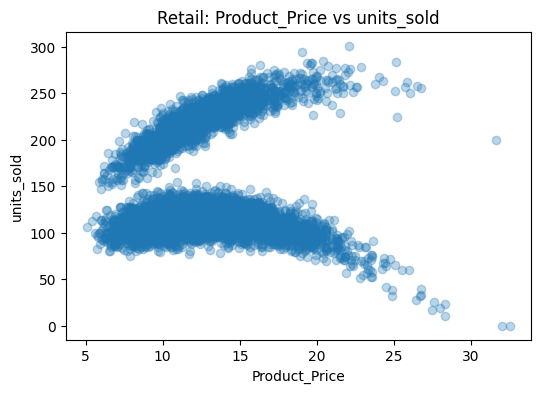

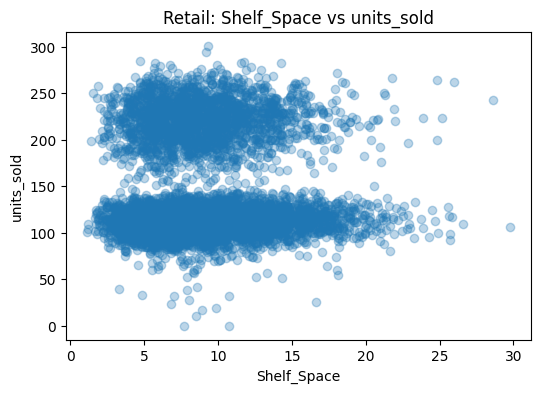

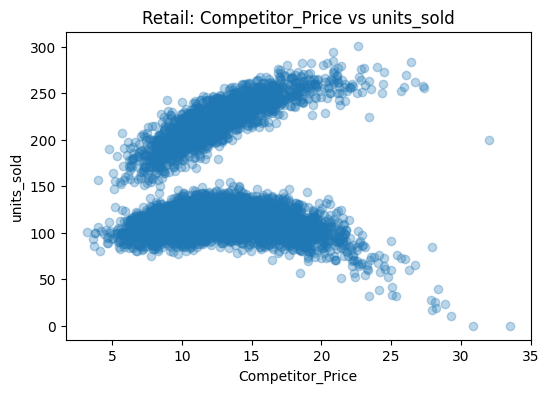

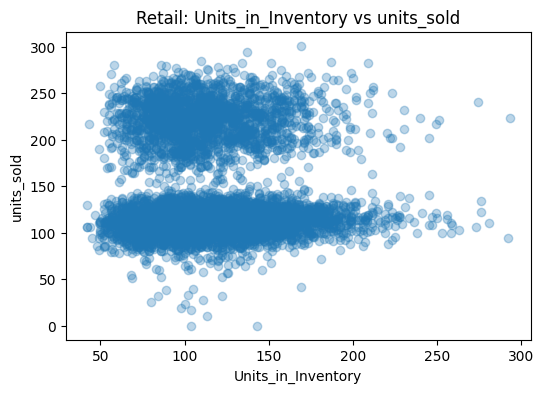

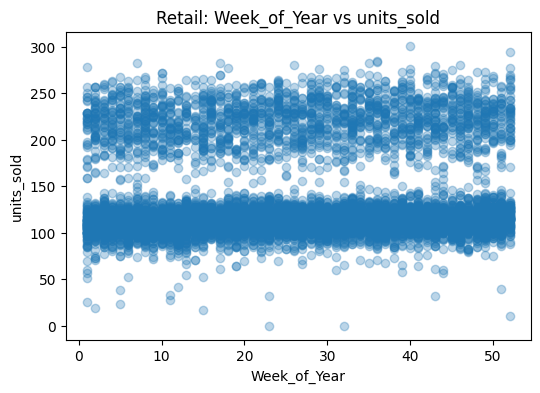

In [ ]:
for col in retail_numeric_predictors:
    plt.figure(figsize=(6,4))
    plt.scatter(retail_train_prep[col], retail_train_prep["units_sold"], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel("units_sold")
    plt.title(f"Retail: {col} vs units_sold")
    plt.show()

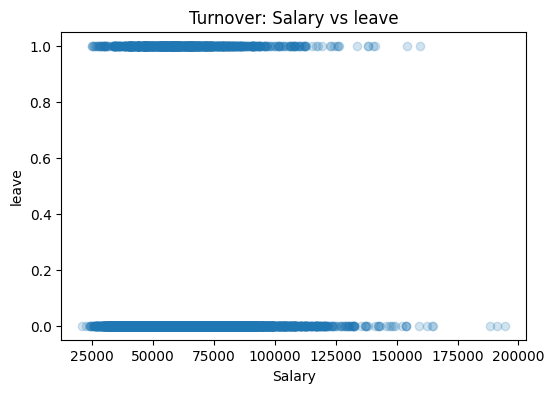

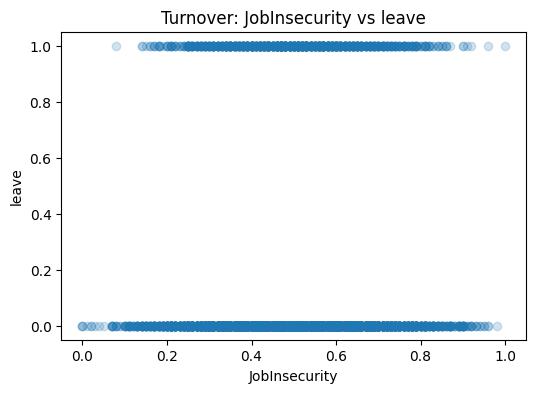

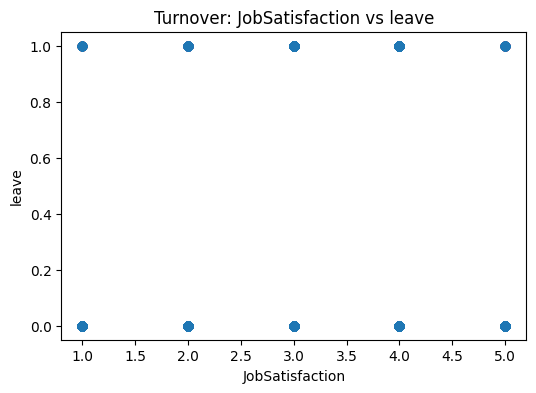

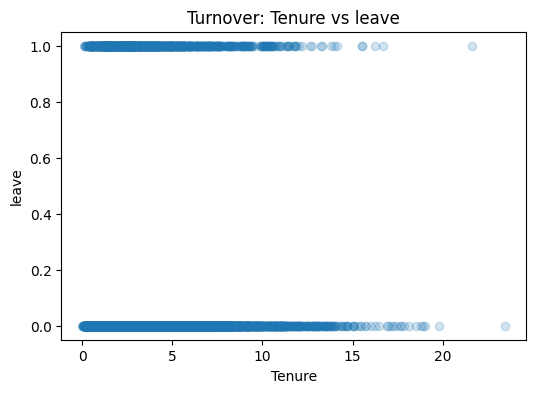

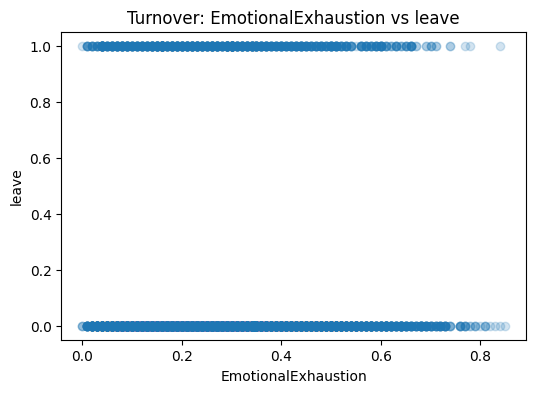

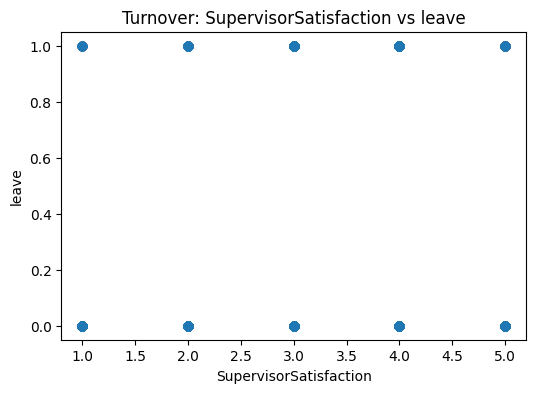

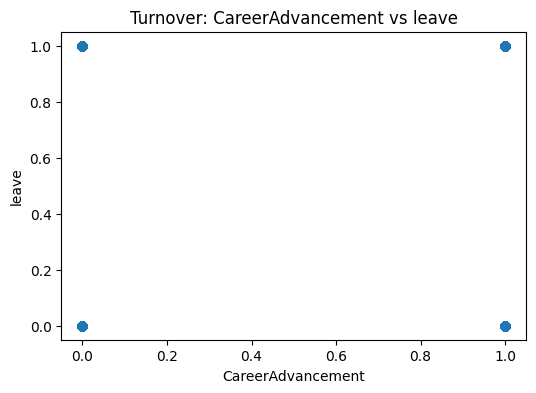

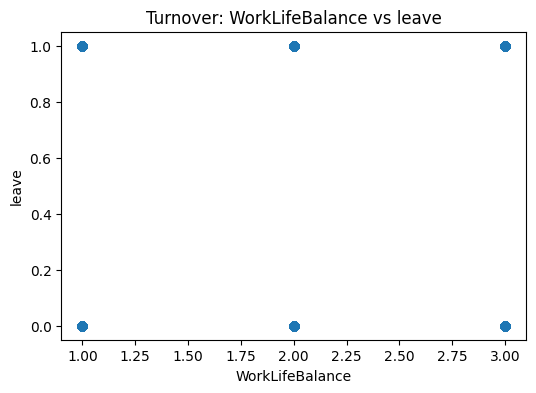

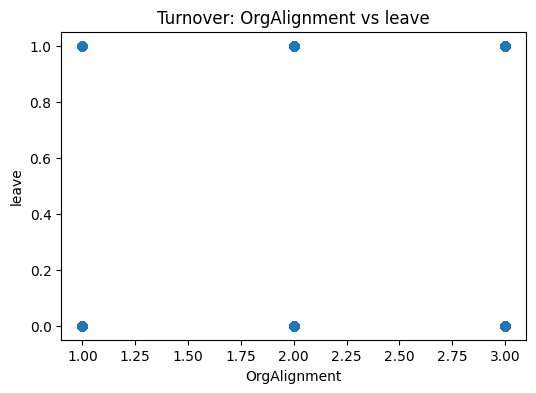

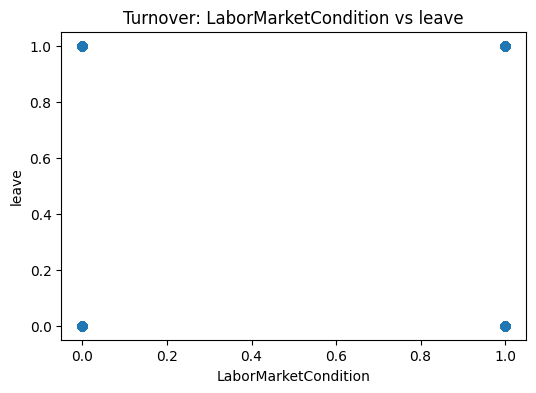

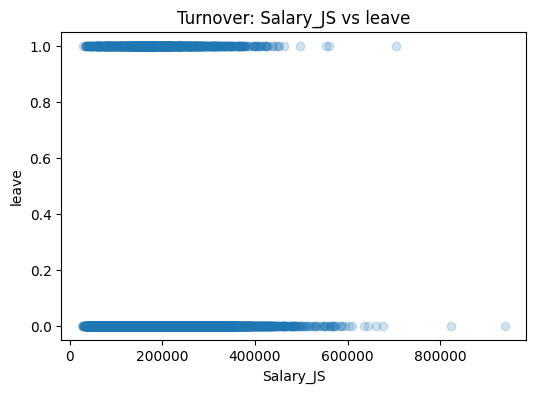

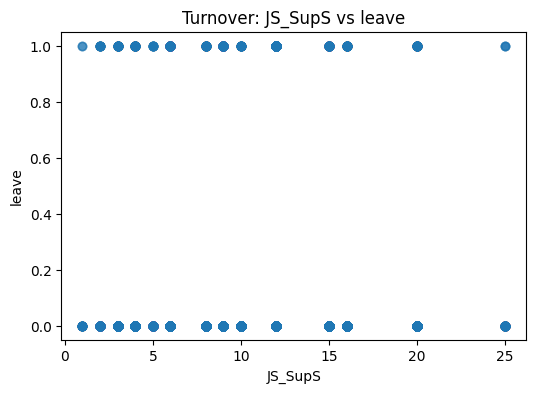

In [ ]:
for col in turnover_numeric_predictors:
    plt.figure(figsize=(6,4))
    plt.scatter(turnover_train_prep[col], turnover_train_prep["leave"].astype(int), alpha=0.2)
    plt.xlabel(col)
    plt.ylabel("leave")
    plt.title(f"Turnover: {col} vs leave")
    plt.show()

**3.2 Retail dataset: parametric models**

Because units_sold is numeric, the retail dataset is treated as a regression problem. The required parametric models are multiple linear regression, multiple linear regression with LASSO, and a generalized additive model.

In [ ]:
retail_mlr_formula = """
units_sold ~ Product_Price + C(Promotion) + C(Product_Category) + C(Store_Location)
+ Shelf_Space + Competitor_Price + C(Season) + C(Day_of_Week)
+ Units_in_Inventory + C(Online_Sales) + Week_of_Year
"""

retail_mlr_model = smf.ols(formula=retail_mlr_formula, data=retail_train_prep).fit()
print(retail_mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     3993.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:20:46   Log-Likelihood:                -32930.
No. Observations:                8000   AIC:                         6.590e+04
Df Residuals:                    7978   BIC:                         6.606e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [ ]:
retail_lasso_model = Pipeline(steps=[
    ("preprocess", retail_preprocessor_scaled),
    ("lasso", Lasso(alpha=0.01, random_state=SEED))
])

retail_lasso_model.fit(X_retail_train, y_retail_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Product_Price',
                                                   'Shelf_Space',
                                                   'Competitor_Price',
                                                   'Units_in_Inventory',
                                                   'Week_of_Year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Promotion',
                                                   'Product_Category',
                                                   'Store_Location', 'Season',
                                                   'Day_of_Week',
                                                   'Online_Sales'])])),
                ('lasso', Lasso(alpha=0.01, random_state=42))])

In [ ]:
retail_spline_vars = ["Product_Price", "Competitor_Price", "Units_in_Inventory", "Week_of_Year"]

retail_spline_bounds = {
    col: {
        "lower": float(X_retail_train[col].min()),
        "upper": float(X_retail_train[col].max())
    }
    for col in retail_spline_vars
}

best_df_default = 5
b = retail_spline_bounds

retail_gam_formula = f"""
units_sold ~
bs(Product_Price, df={best_df_default}, lower_bound={b['Product_Price']['lower']}, upper_bound={b['Product_Price']['upper']}) +
C(Promotion) +
C(Product_Category) +
C(Store_Location) +
Shelf_Space +
bs(Competitor_Price, df={best_df_default}, lower_bound={b['Competitor_Price']['lower']}, upper_bound={b['Competitor_Price']['upper']}) +
C(Season) +
C(Day_of_Week) +
bs(Units_in_Inventory, df={best_df_default}, lower_bound={b['Units_in_Inventory']['lower']}, upper_bound={b['Units_in_Inventory']['upper']}) +
C(Online_Sales) +
bs(Week_of_Year, df={best_df_default}, lower_bound={b['Week_of_Year']['lower']}, upper_bound={b['Week_of_Year']['upper']})
"""

retail_gam_model = smf.ols(formula=retail_gam_formula, data=retail_train_prep).fit()
print(retail_gam_model.summary())

                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     2887.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:20:46   Log-Likelihood:                -32030.
No. Observations:                8000   AIC:                         6.414e+04
Df Residuals:                    7962   BIC:                         6.440e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

**3.3 Turnover dataset: parametric models**

Because leave is binary, the turnover dataset is treated as a classification problem. The required parametric models are logistic regression and logistic regression with LASSO.

In [ ]:
turnover_logit_formula = """
leave ~ Salary + JobInsecurity + JobSatisfaction + Tenure + EmotionalExhaustion
+ C(Domain) + C(OrgLevel) + C(Demographics)
+ SupervisorSatisfaction + CareerAdvancement + WorkLifeBalance
+ OrgAlignment + LaborMarketCondition + Salary_JS + JS_SupS
"""

# Convert the 'leave' column to numeric (int) for statsmodels
turnover_train_prep['leave'] = turnover_train_prep['leave'].astype(int)

turnover_logit_model = smf.logit(formula=turnover_logit_formula, data=turnover_train_prep).fit()
print(turnover_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.420918
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  leave   No. Observations:                 7590
Model:                          Logit   Df Residuals:                     7566
Method:                           MLE   Df Model:                           23
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                0.003969
Time:                        20:20:47   Log-Likelihood:                -3194.8
converged:                       True   LL-Null:                       -3207.5
Covariance Type:            nonrobust   LLR p-value:                    0.3270
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -2.3543      0.490     -4.80

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

turnover_lasso_logit_model = Pipeline(steps=[
    ("preprocess", turnover_preprocessor_scaled),
    ("logit_lasso", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        random_state=SEED,
        max_iter=5000
    ))
])

turnover_lasso_logit_model.fit(X_turnover_train, y_turnover_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Salary', 'JobInsecurity',
                                                   'JobSatisfaction', 'Tenure',
                                                   'EmotionalExhaustion',
                                                   'SupervisorSatisfaction',
                                                   'CareerAdvancement',
                                                   'WorkLifeBalance',
                                                   'OrgAlignment',
                                                   'LaborMarketCondition',
                                                   'Salary_JS', 'JS_SupS']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Domain', 'OrgLevel',
                                                   'Demographics'])])),
                ('logit_lasso',
                 LogisticRegression(max_iter=5000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

**3.4 Non-parametric models**

The tree-based ensemble chosen for both datasets is a random forest. Random forests were selected because they are flexible, can capture nonlinear relationships and interactions, and are less unstable than a single decision tree.

The SVM kernel chosen for both datasets is the radial basis function (RBF) kernel. Based on the bivariate plots, the relationships did not appear strictly linear, so a flexible nonlinear kernel was more appropriate than a purely linear kernel.

The deep learning model uses one hidden layer, with the number of hidden nodes equal to twice the number of input nodes after preprocessing and one-hot encoding, which matches the project instructions.

In [ ]:
# Random forests
retail_rf_model = Pipeline(steps=[
    ("preprocess", ColumnTransformer(
        transformers=[
            ("num", "passthrough", retail_numeric_predictors),
            ("cat", OneHotEncoder(handle_unknown="ignore"), retail_categorical_predictors)
        ]
    )),
    ("rf", RandomForestRegressor(n_estimators=300, random_state=SEED))
])
retail_rf_model.fit(X_retail_train, y_retail_train)

turnover_rf_model = Pipeline(steps=[
    ("preprocess", ColumnTransformer(
        transformers=[
            ("num", "passthrough", turnover_numeric_predictors),
            ("cat", OneHotEncoder(handle_unknown="ignore"), turnover_categorical)
        ]
    )),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=SEED))
])
turnover_rf_model.fit(X_turnover_train, y_turnover_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Salary', 'JobInsecurity',
                                                   'JobSatisfaction', 'Tenure',
                                                   'EmotionalExhaustion',
                                                   'SupervisorSatisfaction',
                                                   'CareerAdvancement',
                                                   'WorkLifeBalance',
                                                   'OrgAlignment',
                                                   'LaborMarketCondition',
                                                   'Salary_JS', 'JS_SupS']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Domain', 'OrgLevel',
                                                   'Demographics'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [ ]:
# SVMs
retail_svm_model = Pipeline(steps=[
    ("preprocess", retail_preprocessor_scaled),
    ("svm", SVR(kernel="rbf", C=1.0, epsilon=0.1))
])
retail_svm_model.fit(X_retail_train, y_retail_train)

turnover_svm_model = Pipeline(steps=[
    ("preprocess", turnover_preprocessor_scaled),
    ("svm", SVC(kernel="rbf", C=1.0, probability=True, random_state=SEED))
])
turnover_svm_model.fit(X_turnover_train, y_turnover_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Salary', 'JobInsecurity',
                                                   'JobSatisfaction', 'Tenure',
                                                   'EmotionalExhaustion',
                                                   'SupervisorSatisfaction',
                                                   'CareerAdvancement',
                                                   'WorkLifeBalance',
                                                   'OrgAlignment',
                                                   'LaborMarketCondition',
                                                   'Salary_JS', 'JS_SupS']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Domain', 'OrgLevel',
                                                   'Demographics'])])),
                ('svm', SVC(probability=True, random_state=42))])

In [ ]:
# Deep learning preprocessing
retail_dl_preprocessor = retail_preprocessor_scaled
turnover_dl_preprocessor = turnover_preprocessor_scaled

X_retail_train_dl = retail_dl_preprocessor.fit_transform(X_retail_train)
X_retail_test_dl = retail_dl_preprocessor.transform(X_retail_test)

X_turnover_train_dl = turnover_dl_preprocessor.fit_transform(X_turnover_train)
X_turnover_test_dl = turnover_dl_preprocessor.transform(X_turnover_test)

if hasattr(X_retail_train_dl, "toarray"):
    X_retail_train_dl = X_retail_train_dl.toarray()
    X_retail_test_dl = X_retail_test_dl.toarray()

if hasattr(X_turnover_train_dl, "toarray"):
    X_turnover_train_dl = X_turnover_train_dl.toarray()
    X_turnover_test_dl = X_turnover_test_dl.toarray()

y_turnover_train_dl = y_turnover_train.astype(int).values
y_turnover_test_dl = y_turnover_test.astype(int).values

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# Retail deep learning model
# one hidden layer
# hidden nodes = 2 * input nodes
# ReLU hidden layer
# ReLU output for numeric outcome
# =========================
def build_retail_dln(input_dim):
    hidden_nodes = 2 * input_dim
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden_nodes, activation="relu"),
        Dense(1, activation="relu")
    ])
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

# =========================
# Turnover deep learning model
# one hidden layer
# hidden nodes = 2 * input nodes
# ReLU hidden layer
# Sigmoid output for binary outcome
# =========================
def build_turnover_dln(input_dim):
    hidden_nodes = 2 * input_dim
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden_nodes, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================
# Fit retail deep learning model
# =========================
tf.keras.backend.clear_session()

retail_dln_model = build_retail_dln(X_retail_train_dl.shape[1])
retail_dln_model.fit(
    np.asarray(X_retail_train_dl, dtype=np.float32),
    np.asarray(y_retail_train.values, dtype=np.float32),
    epochs=30,
    batch_size=32,
    verbose=0
)

# =========================
# Fit turnover deep learning model
# =========================
tf.keras.backend.clear_session()

turnover_dln_model = build_turnover_dln(X_turnover_train_dl.shape[1])
turnover_dln_model.fit(
    np.asarray(X_turnover_train_dl, dtype=np.float32),
    np.asarray(y_turnover_train_dl, dtype=np.float32),
    epochs=30,
    batch_size=32,
    verbose=0
)

**3.5 Principal Component Analysis (PCA)**

For the retail dataset, PCA does not appear necessary because the number of predictors is modest and the original variables remain directly interpretable.

For the turnover dataset, PCA could be considered if the main goal were only to reduce dimensionality among correlated numeric predictors. However, PCA would reduce interpretability, and interpretability is important in an employee-turnover setting. For that reason, PCA is not used in the main analysis.

**3.6 Cluster analysis**

For the retail dataset, clustering based only on predictors could identify groups of products or store situations with similar characteristics, and those cluster labels could then be used as additional predictors in supervised models.

For the turnover dataset, clustering could identify employee profiles with similar patterns of satisfaction, exhaustion, tenure, and organizational alignment. These cluster labels could also be used as additional predictors.

Although clustering could provide useful segmentation information, it is not used as the primary modeling strategy in this project because the main focus is supervised predictive performance.

**4. Assessing model performance**

This section evaluates the predictive models built in Section 3. First, k-fold cross-validation is used on the training data to tune hyperparameters where applicable and estimate aggregated training-set predictive performance. Second, each model is refit on the full training dataset and evaluated on the testing dataset.

The same seed is used throughout for comparability. This section also checks for data drift and concept drift between the training and testing datasets.

In [ ]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)
acc_scorer = make_scorer(accuracy_score)

def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

def regression_metrics(y_true, y_pred, p):
    r2_val = r2_score(y_true, y_pred)
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2_adjusted": adjusted_r2(r2_val, len(y_true), p)
    }

def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }

**4.1 Retail dataset cross-validation and tuning**

In [ ]:
# MLR CV
retail_mlr_cv_pipeline = Pipeline(steps=[
    ("preprocess", ColumnTransformer(
        transformers=[
            ("num", "passthrough", retail_numeric_predictors),
            ("cat", OneHotEncoder(handle_unknown="ignore"), retail_categorical_predictors)
        ]
    )),
    ("model", LinearRegression())
])

retail_mlr_cv_scores = cross_validate(
    retail_mlr_cv_pipeline,
    X_retail_train,
    y_retail_train,
    cv=cv_reg,
    scoring={"rmse": rmse_scorer, "mae": mae_scorer, "r2": r2_scorer}
)

retail_mlr_cv_rmse = -retail_mlr_cv_scores["test_rmse"].mean()
retail_mlr_cv_mae = -retail_mlr_cv_scores["test_mae"].mean()
retail_mlr_cv_r2 = retail_mlr_cv_scores["test_r2"].mean()

In [ ]:
# LASSO CV
retail_lasso_grid = GridSearchCV(
    Pipeline([
        ("preprocess", retail_preprocessor_scaled),
        ("lasso", Lasso(random_state=SEED, max_iter=10000))
    ]),
    param_grid={"lasso__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=cv_reg,
    scoring=rmse_scorer,
    n_jobs=-1
)
retail_lasso_grid.fit(X_retail_train, y_retail_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Product_Price',
                                                                          'Shelf_Space',
                                                                          'Competitor_Price',
                                                                          'Units_in_Inventory',
                                                                          'Week_of_Year']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Promotion',
                                                                          'Product_Category',
                                                                          'Store_Location',
                                                                          'Season',
                                                                          'Day_of_Week',
                                                                          'Online_Sales'])])),
                                       ('lasso',
                                        Lasso(max_iter=10000,
                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
             scoring=make_scorer(rmse, greater_is_better=False, response_method='predict'))

In [ ]:
from patsy import bs, dmatrix, dmatrices
from sklearn.base import BaseEstimator, RegressorMixin
import statsmodels.formula.api as smf
import statsmodels.api as sm # Import statsmodels.api
import pandas as pd
import numpy as np

class RetailGAMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, df_spline=5, spline_bounds=None):
        self.df_spline = df_spline
        self.spline_bounds = spline_bounds
        self.model_ = None
        self.formula_ = None
        self.spline_vars_ = ["Product_Price", "Competitor_Price", "Units_in_Inventory", "Week_of_Year"]
        self.design_info_ = None # Store design_info here

    def fit(self, X, y):
        data = X.copy()
        data["units_sold"] = pd.Series(y).values

        # force numeric
        for col in self.spline_vars_:
            data[col] = pd.to_numeric(data[col], errors="coerce")

        b = self.spline_bounds

        self.formula_ = f"""
        units_sold ~
bs(Product_Price, df={self.df_spline}, lower_bound={b['Product_Price']['lower']}, upper_bound={b['Product_Price']['upper']}) +
C(Promotion) +
C(Product_Category) +
C(Store_Location) +
Shelf_Space +
bs(Competitor_Price, df={self.df_spline}, lower_bound={b['Competitor_Price']['lower']}, upper_bound={b['Competitor_Price']['upper']}) +
C(Season) +
C(Day_of_Week) +
bs(Units_in_Inventory, df={self.df_spline}, lower_bound={b['Units_in_Inventory']['lower']}, upper_bound={b['Units_in_Inventory']['upper']}) +
C(Online_Sales) +
bs(Week_of_Year, df={self.df_spline}, lower_bound={b['Week_of_Year']['lower']}, upper_bound={b['Week_of_Year']['upper']})
        """

        # Manually create the design matrix for the training data
        # This allows us to reliably capture the design_info
        y_design, X_design = dmatrices(self.formula_, data, return_type="dataframe")
        self.design_info_ = X_design.design_info # Capture design_info from the design matrix

        # Now fit the model using the design matrices from patsy
        self.model_ = sm.OLS(y_design, X_design).fit()

        return self

    def predict(self, X):
        X_new = X.copy()

        # force dataframe + numeric
        X_new = pd.DataFrame(X_new).copy()

        for col in self.spline_vars_:
            X_new[col] = pd.to_numeric(X_new[col], errors="coerce")

        # CLIP values to spline bounds to avoid patsy error
        b = self.spline_bounds
        for col in self.spline_vars_:
            X_new[col] = X_new[col].clip(
                lower=b[col]["lower"],
                upper=b[col]["upper"]
            )

        # Explicitly create the design matrix for prediction using the stored design_info
        exog_pred = dmatrix(self.design_info_, X_new)

        preds = self.model_.predict(exog_pred)
        return np.asarray(preds)

retail_gam_grid = GridSearchCV(
    RetailGAMRegressor(spline_bounds=retail_spline_bounds),
    param_grid={"df_spline": [4, 5, 6]},
    cv=cv_reg,
    scoring=rmse_scorer,
    n_jobs=1,
    error_score="raise"
)
retail_gam_grid.fit(X_retail_train, y_retail_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=RetailGAMRegressor(spline_bounds={'Competitor_Price': {'lower': 3.19,
                                                                              'upper': 33.49},
                                                         'Product_Price': {'lower': 5.08,
                                                                           'upper': 32.52},
                                                         'Units_in_Inventory': {'lower': 42.0,
                                                                                'upper': 293.0},
                                                         'Week_of_Year': {'lower': 1.0,
                                                                          'upper': 52.0}}),
             n_jobs=1, param_grid={'df_spline': [4, 5, 6]},
             scoring=make_scorer(rmse, greater_is_better=False, response_method='predict'))

In [ ]:
# =========================
# Retail Random Forest CV (very fast version)
# =========================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

retail_rf_tune_pipeline = Pipeline(steps=[
    ("preprocess", ColumnTransformer(
        transformers=[
            ("num", "passthrough", retail_numeric_predictors),
            ("cat", OneHotEncoder(handle_unknown="ignore"), retail_categorical_predictors)
        ]
    )),
    ("rf", RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1
    ))
])

retail_rf_param_grid = {
    "rf__n_estimators": [100],
    "rf__max_depth": [None, 10],
    "rf__min_samples_leaf": [1, 5]
}

retail_rf_grid = GridSearchCV(
    estimator=retail_rf_tune_pipeline,
    param_grid=retail_rf_param_grid,
    cv=3,
    scoring=rmse_scorer,
    n_jobs=-1,
    verbose=1
)

retail_rf_grid.fit(X_retail_train, y_retail_train)

print("Best retail random forest parameters:", retail_rf_grid.best_params_)
print("Best retail random forest CV RMSE:", -retail_rf_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best retail random forest parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}
Best retail random forest CV RMSE: 8.948502064063797


In [ ]:
# SVM CV
retail_svm_grid = GridSearchCV(
    Pipeline([
        ("preprocess", retail_preprocessor_scaled),
        ("svm", SVR(kernel="rbf"))
    ]),
    param_grid={
        "svm__C": [0.1, 1.0, 10.0],
        "svm__gamma": ["scale", 0.01, 0.1],
        "svm__epsilon": [0.1, 0.5]
    },
    cv=cv_reg,
    scoring=rmse_scorer,
    n_jobs=-1
)
retail_svm_grid.fit(X_retail_train, y_retail_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Product_Price',
                                                                          'Shelf_Space',
                                                                          'Competitor_Price',
                                                                          'Units_in_Inventory',
                                                                          'Week_of_Year']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Promotion',
                                                                          'Product_Category',
                                                                          'Store_Location',
                                                                          'Season',
                                                                          'Day_of_Week',
                                                                          'Online_Sales'])])),
                                       ('svm', SVR())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1.0, 10.0], 'svm__epsilon': [0.1, 0.5],
                         'svm__gamma': ['scale', 0.01, 0.1]},
             scoring=make_scorer(rmse, greater_is_better=False, response_method='predict'))

In [ ]:
# =========================
# Retail Deep Learning - fast all-in-one code
# =========================

import numpy as np
import pandas as pd
import gc
import tensorflow as tf

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# -------------------------
# Seed
# -------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------
# Helper metric
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# -------------------------
# Build retail deep learning model
# one hidden layer
# hidden nodes = 2 * input nodes
# ReLU hidden layer
# ReLU output layer for numeric outcome
# -------------------------
def build_retail_dln(input_dim):
    hidden_nodes = 2 * input_dim
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden_nodes, activation="relu"),
        Dense(1, activation="relu")
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

# -------------------------
# Prepare deep learning matrices
# assumes these already exist:
# X_retail_train
# X_retail_test
# retail_dl_preprocessor
# y_retail_train
# y_retail_test
# -------------------------
X_retail_train_dl = retail_dl_preprocessor.fit_transform(X_retail_train)
X_retail_test_dl = retail_dl_preprocessor.transform(X_retail_test)

if hasattr(X_retail_train_dl, "toarray"):
    X_retail_train_dl = X_retail_train_dl.toarray()
    X_retail_test_dl = X_retail_test_dl.toarray()

X_retail_train_dl = np.asarray(X_retail_train_dl, dtype=np.float32)
X_retail_test_dl = np.asarray(X_retail_test_dl, dtype=np.float32)

y_retail_train_dl = np.asarray(y_retail_train.values, dtype=np.float32).reshape(-1)
y_retail_test_dl = np.asarray(y_retail_test.values, dtype=np.float32).reshape(-1)

print("X_retail_train_dl shape:", X_retail_train_dl.shape)
print("X_retail_test_dl shape :", X_retail_test_dl.shape)
print("y_retail_train_dl shape:", y_retail_train_dl.shape)
print("y_retail_test_dl shape :", y_retail_test_dl.shape)

# -------------------------
# Fast CV helper
# uses only:
# - epochs = 10
# - batch_size = 32
# - 3 folds
# to keep runtime manageable
# -------------------------
def retail_dln_cv_fast(X, y, epochs=10, batch_size=32, n_splits=3):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    rmses, maes, r2s = [], [], []

    fold_num = 1
    for train_idx, valid_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[valid_idx]
        y_tr, y_val = y[train_idx], y[valid_idx]

        tf.keras.backend.clear_session()

        model = build_retail_dln(X.shape[1])
        model.fit(
            X_tr,
            y_tr,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        preds = model.predict(X_val, verbose=0).reshape(-1)

        fold_rmse = rmse(y_val, preds)
        fold_mae = mean_absolute_error(y_val, preds)
        fold_r2 = r2_score(y_val, preds)

        rmses.append(fold_rmse)
        maes.append(fold_mae)
        r2s.append(fold_r2)

        print(
            f"Fold {fold_num}: RMSE={fold_rmse:.4f}, "
            f"MAE={fold_mae:.4f}, R2={fold_r2:.4f}"
        )

        del model
        gc.collect()
        fold_num += 1

    return pd.DataFrame([{
        "epochs": epochs,
        "batch_size": batch_size,
        "CV_RMSE": float(np.mean(rmses)),
        "CV_MAE": float(np.mean(maes)),
        "CV_R2": float(np.mean(r2s))
    }])

# -------------------------
# Run fast CV
# -------------------------
retail_dln_cv_results = retail_dln_cv_fast(
    X_retail_train_dl,
    y_retail_train_dl,
    epochs=10,
    batch_size=32,
    n_splits=3
)

print("\nRetail DL CV Results:")
display(retail_dln_cv_results)

# -------------------------
# Fit final model using best settings
# -------------------------
best_retail_dln = retail_dln_cv_results.iloc[0]

tf.keras.backend.clear_session()

retail_dln_final = build_retail_dln(X_retail_train_dl.shape[1])
retail_dln_final.fit(
    X_retail_train_dl,
    y_retail_train_dl,
    epochs=int(best_retail_dln["epochs"]),
    batch_size=int(best_retail_dln["batch_size"]),
    verbose=0
)

# -------------------------
# Final predictions
# -------------------------
retail_dln_train_preds = retail_dln_final.predict(X_retail_train_dl, verbose=0).reshape(-1)
retail_dln_test_preds = retail_dln_final.predict(X_retail_test_dl, verbose=0).reshape(-1)

# -------------------------
# Final metrics
# -------------------------
retail_dln_train_rmse = rmse(y_retail_train_dl, retail_dln_train_preds)
retail_dln_test_rmse = rmse(y_retail_test_dl, retail_dln_test_preds)

retail_dln_train_mae = mean_absolute_error(y_retail_train_dl, retail_dln_train_preds)
retail_dln_test_mae = mean_absolute_error(y_retail_test_dl, retail_dln_test_preds)

retail_dln_train_r2 = r2_score(y_retail_train_dl, retail_dln_train_preds)
retail_dln_test_r2 = r2_score(y_retail_test_dl, retail_dln_test_preds)

print("\nBest Retail DL Parameters:")
print(best_retail_dln)

print("\nRetail DL Final Training Metrics")
print("RMSE:", retail_dln_train_rmse)
print("MAE :", retail_dln_train_mae)
print("R2  :", retail_dln_train_r2)

print("\nRetail DL Final Testing Metrics")
print("RMSE:", retail_dln_test_rmse)
print("MAE :", retail_dln_test_mae)
print("R2  :", retail_dln_test_r2)

X_retail_train_dl shape: (8000, 27)
X_retail_test_dl shape : (2000, 27)
y_retail_train_dl shape: (8000,)
y_retail_test_dl shape : (2000,)
Fold 1: RMSE=20.4673, MAE=14.4832, R2=0.8370
Fold 2: RMSE=19.5409, MAE=14.1710, R2=0.8478
Fold 3: RMSE=21.2877, MAE=15.5075, R2=0.8206

Retail DL CV Results:


,epochs,batch_size,CV_RMSE,CV_MAE,CV_R2
0,10,32,20.431955,14.720579,0.835111



Best Retail DL Parameters:
epochs        10.000000
batch_size    32.000000
CV_RMSE       20.431955
CV_MAE        14.720579
CV_R2          0.835111
Name: 0, dtype: float64

Retail DL Final Training Metrics
RMSE: 12.152357
MAE : 8.947065353393555
R2  : 0.9417381882667542

Retail DL Final Testing Metrics
RMSE: 45.059498
MAE : 43.07294845581055
R2  : -2.3531997203826904


**4.2 Retail final evaluation**

In [ ]:
retail_models_final = {
    "MLR": retail_mlr_cv_pipeline.fit(X_retail_train, y_retail_train),
    "LASSO": retail_lasso_grid.best_estimator_,
    "GAM": retail_gam_grid.best_estimator_,
    "RandomForest": retail_rf_grid.best_estimator_,
    "SVM": retail_svm_grid.best_estimator_
}

best_retail_dln = retail_dln_cv_results.iloc[0]
retail_dln_final = build_retail_dln(X_retail_train_dl.shape[1])
retail_dln_final.fit(
    X_retail_train_dl, y_retail_train.values,
    epochs=int(best_retail_dln["epochs"]),
    batch_size=int(best_retail_dln["batch_size"]),
    verbose=0
)

retail_results_section4 = []
for name, model in retail_models_final.items():
    train_preds = model.predict(X_retail_train)
    test_preds = model.predict(X_retail_test)
    retail_results_section4.append({
        "Model": name,
        "Train": regression_metrics(y_retail_train, train_preds, len(retail_predictors)),
        "Test": regression_metrics(y_retail_test, test_preds, len(retail_predictors))
    })

retail_dln_train_preds = retail_dln_final.predict(X_retail_train_dl, verbose=0).ravel()
retail_dln_test_preds = retail_dln_final.predict(X_retail_test_dl, verbose=0).ravel()

retail_results_section4.append({
    "Model": "DeepLearning",
    "Train": regression_metrics(y_retail_train.values, retail_dln_train_preds, X_retail_train_dl.shape[1]),
    "Test": regression_metrics(y_retail_test.values, retail_dln_test_preds, X_retail_test_dl.shape[1])
})

retail_results_section4

[{'Model': 'MLR',
  'Train': {'RMSE': np.float64(14.839317827634094),
   'MAE': 10.59174908298561,
   'R2_adjusted': 0.9130061377430952},
  'Test': {'RMSE': np.float64(48.43118311885589),
   'MAE': 46.47307226973668,
   'R2_adjusted': -2.8952316213760256}},
 {'Model': 'LASSO',
  'Train': {'RMSE': np.float64(14.83973351144053),
   'MAE': 10.592015926399174,
   'R2_adjusted': 0.9130012638739984},
  'Test': {'RMSE': np.float64(48.396420556490554),
   'MAE': 46.44256930702059,
   'R2_adjusted': -2.88964184936103}},
 {'Model': 'GAM',
  'Train': {'RMSE': np.float64(13.263947635735652),
   'MAE': 9.887173477361824,
   'R2_adjusted': 0.930496554138759},
  'Test': {'RMSE': np.float64(44.8763425889046),
   'MAE': 43.205613183918786,
   'R2_adjusted': -2.3443986521784637}},
 {'Model': 'RandomForest',
  'Train': {'RMSE': np.float64(5.966649189908364),
   'MAE': 4.64833647373471,
   'R2_adjusted': 0.9859355825703411},
  'Test': {'RMSE': np.float64(41.57099490089414),
   'MAE': 36.823302248758615,
 

**4.3 Turnover dataset cross-validation and tuning**

In [ ]:
turnover_logit_cv_pipeline = Pipeline(steps=[
    ("preprocess", ColumnTransformer(
        transformers=[
            ("num", "passthrough", turnover_numeric_predictors),
            ("cat", OneHotEncoder(handle_unknown="ignore"), turnover_categorical)
        ]
    )),
    ("model", LogisticRegression(max_iter=5000, random_state=SEED))
])

turnover_logit_cv_scores = cross_validate(
    turnover_logit_cv_pipeline,
    X_turnover_train,
    y_turnover_train,
    cv=cv_clf,
    scoring={"accuracy": acc_scorer}
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.model_selection import GridSearchCV

turnover_lasso_grid = GridSearchCV(
    turnover_lasso_logit_model,
    param_grid={"logit_lasso__C": [0.01, 0.1, 1.0, 10.0]},
    cv=cv_clf,
    scoring="accuracy",
    n_jobs=-1
)
turnover_lasso_grid.fit(X_turnover_train, y_turnover_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Salary',
                                                                          'JobInsecurity',
                                                                          'JobSatisfaction',
                                                                          'Tenure',
                                                                          'EmotionalExhaustion',
                                                                          'SupervisorSatisfaction',
                                                                          'CareerAdvancement',
                                                                          'WorkLifeBalance',
                                                                          'OrgAlignment',
                                                                          'LaborMarketCondition',
                                                                          'Salary_JS',
                                                                          'JS_SupS']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Domain',
                                                                          'OrgLevel',
                                                                          'Demographics'])])),
                                       ('logit_lasso',
                                        LogisticRegression(max_iter=5000,
                                                           penalty='l1',
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1, param_grid={'logit_lasso__C': [0.01, 0.1, 1.0, 10.0]},
             scoring='accuracy')

In [ ]:
# =========================
# Turnover SVM CV (very fast version)
# =========================

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

turnover_svm_tune_pipeline = Pipeline(steps=[
    ("preprocess", turnover_preprocessor_scaled),
    ("svm", SVC(
        kernel="rbf",
        probability=True,
        random_state=SEED
    ))
])

turnover_svm_param_grid = {
    "svm__C": [1.0, 10.0],
    "svm__gamma": ["scale"]
}

turnover_svm_grid = GridSearchCV(
    estimator=turnover_svm_tune_pipeline,
    param_grid=turnover_svm_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

turnover_svm_grid.fit(X_turnover_train, y_turnover_train)

print("Best turnover SVM parameters:", turnover_svm_grid.best_params_)
print("Best turnover SVM CV accuracy:", turnover_svm_grid.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best turnover SVM parameters: {'svm__C': 1.0, 'svm__gamma': 'scale'}
Best turnover SVM CV accuracy: 0.8500658761528327


In [ ]:
def turnover_dln_cv(X, y, epochs_list=[20, 30], batch_sizes=[16, 32], n_splits=5):
    results = []
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for epochs in epochs_list:
        for batch_size in batch_sizes:
            accs = []
            for train_idx, valid_idx in skf.split(X, y):
                X_tr, X_val = X[train_idx], X[valid_idx]
                y_tr, y_val = y[train_idx], y[valid_idx]

                model = build_turnover_dln(X.shape[1])
                model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size, verbose=0)
                probs = model.predict(X_val, verbose=0).ravel()
                preds = (probs >= 0.5).astype(int)
                accs.append(accuracy_score(y_val, preds))

            results.append({
                "epochs": epochs,
                "batch_size": batch_size,
                "CV_Accuracy": np.mean(accs)
            })

    return pd.DataFrame(results).sort_values("CV_Accuracy", ascending=False)

turnover_dln_cv_results = turnover_dln_cv(X_turnover_train_dl, y_turnover_train_dl)
turnover_dln_cv_results

,epochs,batch_size,CV_Accuracy
0,20,16,0.850066
1,20,32,0.849934
3,30,32,0.849934
2,30,16,0.849539


**4.4 Turnover final evaluation**

In [ ]:
turnover_models_final = {
    "LogisticRegression": turnover_logit_cv_pipeline.fit(X_turnover_train, y_turnover_train),
    "LASSO_Logistic": turnover_lasso_grid.best_estimator_,
    "RandomForest": turnover_rf_grid.best_estimator_,
    "SVM": turnover_svm_grid.best_estimator_
}

best_turnover_dln = turnover_dln_cv_results.iloc[0]
turnover_dln_final = build_turnover_dln(X_turnover_train_dl.shape[1])
turnover_dln_final.fit(
    X_turnover_train_dl, y_turnover_train_dl,
    epochs=int(best_turnover_dln["epochs"]),
    batch_size=int(best_turnover_dln["batch_size"]),
    verbose=0
)

turnover_results_section4 = []
for name, model in turnover_models_final.items():
    train_preds = model.predict(X_turnover_train)
    test_preds = model.predict(X_turnover_test)
    turnover_results_section4.append({
        "Model": name,
        "Train": classification_metrics(y_turnover_train.astype(int), train_preds.astype(int)),
        "Test": classification_metrics(y_turnover_test.astype(int), test_preds.astype(int))
    })

turnover_dln_train_probs = turnover_dln_final.predict(X_turnover_train_dl, verbose=0).ravel()
turnover_dln_test_probs = turnover_dln_final.predict(X_turnover_test_dl, verbose=0).ravel()

turnover_dln_train_preds = (turnover_dln_train_probs >= 0.5).astype(int)
turnover_dln_test_preds = (turnover_dln_test_probs >= 0.5).astype(int)

turnover_results_section4.append({
    "Model": "DeepLearning",
    "Train": classification_metrics(y_turnover_train_dl, turnover_dln_train_preds),
    "Test": classification_metrics(y_turnover_test_dl, turnover_dln_test_preds)
})

turnover_results_section4

[{'Model': 'LogisticRegression',
  'Train': {'Accuracy': 0.8500658761528327,
   'TP': np.int64(0),
   'TN': np.int64(6452),
   'FP': np.int64(0),
   'FN': np.int64(1138)},
  'Test': {'Accuracy': 0.68,
   'TP': np.int64(0),
   'TN': np.int64(1360),
   'FP': np.int64(0),
   'FN': np.int64(640)}},
 {'Model': 'LASSO_Logistic',
  'Train': {'Accuracy': 0.8500658761528327,
   'TP': np.int64(0),
   'TN': np.int64(6452),
   'FP': np.int64(0),
   'FN': np.int64(1138)},
  'Test': {'Accuracy': 0.68,
   'TP': np.int64(0),
   'TN': np.int64(1360),
   'FP': np.int64(0),
   'FN': np.int64(640)}},
 {'Model': 'RandomForest',
  'Train': {'Accuracy': 0.8500658761528327,
   'TP': np.int64(0),
   'TN': np.int64(6452),
   'FP': np.int64(0),
   'FN': np.int64(1138)},
  'Test': {'Accuracy': 0.68,
   'TP': np.int64(0),
   'TN': np.int64(1360),
   'FP': np.int64(0),
   'FN': np.int64(640)}},
 {'Model': 'SVM',
  'Train': {'Accuracy': 0.8500658761528327,
   'TP': np.int64(0),
   'TN': np.int64(6452),
   'FP': np.i

In [ ]:
# =========================
# Turnover Random Forest CV
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

turnover_rf_tune_pipeline = Pipeline(steps=[
    ("preprocess", ColumnTransformer(
        transformers=[
            ("num", "passthrough", turnover_numeric_predictors),
            ("cat", OneHotEncoder(handle_unknown="ignore"), turnover_categorical)
        ]
    )),
    ("rf", RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1
    ))
])

turnover_rf_param_grid = {
    "rf__n_estimators": [100],
    "rf__max_depth": [None, 10],
    "rf__min_samples_leaf": [1, 5]
}

turnover_rf_grid = GridSearchCV(
    estimator=turnover_rf_tune_pipeline,
    param_grid=turnover_rf_param_grid,
    cv=cv_clf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

turnover_rf_grid.fit(X_turnover_train, y_turnover_train)

print("Best turnover random forest parameters:", turnover_rf_grid.best_params_)
print("Best turnover random forest CV accuracy:", turnover_rf_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best turnover random forest parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}
Best turnover random forest CV accuracy: 0.8500658761528326


**4.5 Data drift analysis**

In [ ]:
def numeric_drift_table(train_df, test_df, numeric_cols):
    rows = []
    for col in numeric_cols:
        stat, p = ks_2samp(train_df[col], test_df[col])
        rows.append({"Variable": col, "KS_statistic": stat, "p_value": p})
    return pd.DataFrame(rows).sort_values("p_value")

def categorical_drift_table(train_df, test_df, cat_cols):
    rows = []
    for col in cat_cols:
        train_counts = train_df[col].astype(str).value_counts()
        test_counts = test_df[col].astype(str).value_counts()
        all_levels = sorted(set(train_counts.index).union(set(test_counts.index)))
        train_vals = np.array([train_counts.get(level, 0) for level in all_levels])
        test_vals = np.array([test_counts.get(level, 0) for level in all_levels])
        contingency = np.vstack([train_vals, test_vals])
        chi2, p, _, _ = chi2_contingency(contingency)
        rows.append({"Variable": col, "Chi2_statistic": chi2, "p_value": p})
    return pd.DataFrame(rows).sort_values("p_value")

retail_numeric_drift = numeric_drift_table(retail_train_prep, retail_test_prep, retail_numeric_predictors)
retail_categorical_drift = categorical_drift_table(retail_train_prep, retail_test_prep, retail_categorical_predictors)

turnover_numeric_drift = numeric_drift_table(turnover_train_prep, turnover_test_prep, turnover_numeric_predictors)
turnover_categorical_drift = categorical_drift_table(turnover_train_prep, turnover_test_prep, turnover_categorical)

print("Retail numeric drift:")
display(retail_numeric_drift)
print("Retail categorical drift:")
display(retail_categorical_drift)

print("Turnover numeric drift:")
display(turnover_numeric_drift)
print("Turnover categorical drift:")
display(turnover_categorical_drift)

Retail numeric drift:


,Variable,KS_statistic,p_value
3,Units_in_Inventory,0.794500,8.646149e-322
1,Shelf_Space,0.658500,2.583963e-321
2,Competitor_Price,0.544375,4.772674e-321
0,Product_Price,0.493000,6.679768e-321
4,Week_of_Year,0.045000,3.008424e-03


Retail categorical drift:


,Variable,Chi2_statistic,p_value
3,Season,475.472232,9.861201e-103
1,Product_Category,387.454398,1.154818e-83
5,Online_Sales,315.955703,1.101169e-70
0,Promotion,286.720055,2.577748e-64
2,Store_Location,175.407667,8.141587e-39
4,Day_of_Week,139.212360,1.469477e-27


Turnover numeric drift:


,Variable,KS_statistic,p_value
6,CareerAdvancement,0.643285,2.727242e-321
11,JS_SupS,0.511308,5.642230e-321
5,SupervisorSatisfaction,0.494565,6.294396e-321
4,EmotionalExhaustion,0.481276,6.803284e-321
10,Salary_JS,0.412326,2.802284e-242
1,JobInsecurity,0.410800,1.986118e-240
8,OrgAlignment,0.403822,4.554192e-232
2,JobSatisfaction,0.356363,1.716477e-179
9,LaborMarketCondition,0.303839,1.044295e-129
0,Salary,0.299612,4.495129e-126


Turnover categorical drift:


,Variable,Chi2_statistic,p_value
0,Domain,1326.696382,1.800129e-283
1,OrgLevel,67.400585,1.537187e-14
2,Demographics,24.728722,1.759423e-05


In [ ]:
**4.6 Concept drift analysis**

SyntaxError: invalid syntax (650560250.py, line 1)

In [ ]:
def summarize_train_test_gap_reg(results_list):
    rows = []
    for item in results_list:
        rows.append({
            "Model": item["Model"],
            "Train_RMSE": item["Train"]["RMSE"],
            "Test_RMSE": item["Test"]["RMSE"],
            "RMSE_Gap": item["Test"]["RMSE"] - item["Train"]["RMSE"],
            "Train_MAE": item["Train"]["MAE"],
            "Test_MAE": item["Test"]["MAE"],
            "MAE_Gap": item["Test"]["MAE"] - item["Train"]["MAE"],
            "Train_R2_adjusted": item["Train"]["R2_adjusted"],
            "Test_R2_adjusted": item["Test"]["R2_adjusted"],
            "R2_Gap": item["Train"]["R2_adjusted"] - item["Test"]["R2_adjusted"]
        })
    return pd.DataFrame(rows)

def summarize_train_test_gap_clf(results_list):
    rows = []
    for item in results_list:
        rows.append({
            "Model": item["Model"],
            "Train_Accuracy": item["Train"]["Accuracy"],
            "Test_Accuracy": item["Test"]["Accuracy"],
            "Accuracy_Gap": item["Train"]["Accuracy"] - item["Test"]["Accuracy"]
        })
    return pd.DataFrame(rows)

retail_gap_table = summarize_train_test_gap_reg(retail_results_section4)
turnover_gap_table = summarize_train_test_gap_clf(turnover_results_section4)

display(retail_gap_table)
display(turnover_gap_table)

Data drift and concept drift are evaluated separately but interpreted together.

Evidence of data drift is stronger when predictor distributions differ meaningfully between the training and testing datasets.
Evidence of concept drift is stronger when a model that performs well during cross-validation and on the training data shows a noticeable deterioration on the testing data.
If both distributional shift and testing-performance deterioration are present, the case for drift is stronger.

5. **Reporting results**


This section reports the final results for the predictive models fit in Sections 3 and 4. The performance tables report final fitted training and testing results, while the hyperparameter tables report the best settings selected using cross-validation.

In [ ]:
retail_cv_summary = pd.DataFrame([
    {"Model": "MLR", "CV_RMSE": retail_mlr_cv_rmse, "CV_MAE": retail_mlr_cv_mae, "CV_R2": retail_mlr_cv_r2, "Best_Params": "None"},
    {"Model": "LASSO", "CV_RMSE": -retail_lasso_grid.best_score_, "CV_MAE": np.nan, "CV_R2": np.nan, "Best_Params": str(retail_lasso_grid.best_params_)},
    {"Model": "GAM", "CV_RMSE": -retail_gam_grid.best_score_, "CV_MAE": np.nan, "CV_R2": np.nan, "Best_Params": str(retail_gam_grid.best_params_)},
    {"Model": "RandomForest", "CV_RMSE": -retail_rf_grid.best_score_, "CV_MAE": np.nan, "CV_R2": np.nan, "Best_Params": str(retail_rf_grid.best_params_)},
    {"Model": "SVM", "CV_RMSE": -retail_svm_grid.best_score_, "CV_MAE": np.nan, "CV_R2": np.nan, "Best_Params": str(retail_svm_grid.best_params_)},
    {"Model": "DeepLearning", "CV_RMSE": retail_dln_cv_results.iloc[0]["CV_RMSE"], "CV_MAE": retail_dln_cv_results.iloc[0]["CV_MAE"], "CV_R2": retail_dln_cv_results.iloc[0]["CV_R2"], "Best_Params": f"epochs={int(retail_dln_cv_results.iloc[0]['epochs'])}, batch_size={int(retail_dln_cv_results.iloc[0]['batch_size'])}"}
])

turnover_cv_summary = pd.DataFrame([
    {"Model": "LogisticRegression", "CV_Accuracy": turnover_logit_cv_scores["test_accuracy"].mean(), "Best_Params": "None"},
    {"Model": "LASSO_Logistic", "CV_Accuracy": turnover_lasso_grid.best_score_, "Best_Params": str(turnover_lasso_grid.best_params_)},
    {"Model": "RandomForest", "CV_Accuracy": turnover_rf_grid.best_score_, "Best_Params": str(turnover_rf_grid.best_params_)},
    {"Model": "SVM", "CV_Accuracy": turnover_svm_grid.best_score_, "Best_Params": str(turnover_svm_grid.best_params_)},
    {"Model": "DeepLearning", "CV_Accuracy": turnover_dln_cv_results.iloc[0]["CV_Accuracy"], "Best_Params": f"epochs={int(turnover_dln_cv_results.iloc[0]['epochs'])}, batch_size={int(turnover_dln_cv_results.iloc[0]['batch_size'])}"}
])

**5.1 Retail dataset results**

In [ ]:
retail_results_table = pd.DataFrame([
    {
        "Modeling technique": item["Model"],
        "RMSE - training": item["Train"]["RMSE"],
        "RMSE - testing": item["Test"]["RMSE"],
        "Adjusted R2 - training": item["Train"]["R2_adjusted"],
        "Adjusted R2 - testing": item["Test"]["R2_adjusted"],
        "MAE - training": item["Train"]["MAE"],
        "MAE - testing": item["Test"]["MAE"]
    }
    for item in retail_results_section4
]).sort_values("RMSE - testing")

retail_hyperparams_table = retail_cv_summary[["Model", "Best_Params"]].copy()

display(retail_results_table)
display(retail_hyperparams_table)

**5.2 Turnover dataset results**

In [ ]:
turnover_results_table = pd.DataFrame([
    {
        "Modeling technique": item["Model"],
        "Accuracy - training": item["Train"]["Accuracy"],
        "Accuracy - testing": item["Test"]["Accuracy"],
        "TP - training": item["Train"]["TP"],
        "TP - testing": item["Test"]["TP"],
        "TN - training": item["Train"]["TN"],
        "TN - testing": item["Test"]["TN"],
        "FP - training": item["Train"]["FP"],
        "FP - testing": item["Test"]["FP"],
        "FN - training": item["Train"]["FN"],
        "FN - testing": item["Test"]["FN"]
    }
    for item in turnover_results_section4
]).sort_values("Accuracy - testing", ascending=False)

turnover_hyperparams_table = turnover_cv_summary[["Model", "Best_Params"]].copy()

display(turnover_results_table)
display(turnover_hyperparams_table)

**5.3 Appropriate metrics for comparing models**

For the retail dataset, RMSE and MAE are the most practical measures because they show prediction error in the same units as units sold, which makes the results easier to understand. RMSE is helpful when larger mistakes matter more, since it penalizes big errors more heavily. MAE, on the other hand, gives a clear picture of the average size of the model’s errors. Adjusted R² is also valuable because it shows how much of the variation in sales the model explains, while also taking into account how complex the model is.

For the turnover dataset, accuracy gives a general idea of how well the model classifies employees, but it should not be used on its own. The confusion matrix is especially important because it shows the numbers of true positives, true negatives, false positives, and false negatives, which helps us understand the kinds of mistakes the model is making. In employee turnover prediction, these errors do not carry the same weight. For example, missing an employee who is actually likely to leave could be more costly than wrongly identifying someone as at risk when they would have stayed.

**5.4 Variable importance**

Because variable importance is measured differently across model families, raw importance values are not directly comparable across all models. To make the results comparable, each model-specific importance measure is converted into a rank, and the aggregate mean rank is used as the overall summary.

In [ ]:
# =========================
# FAST VARIABLE IMPORTANCE - ALL IN ONE
# Retail + Turnover
# =========================

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

# -------------------------
# Helper functions
# -------------------------
def rank_from_series(s, ascending=False):
    s = s.copy().dropna()
    s = s.sort_values(ascending=ascending)
    return pd.Series(range(1, len(s) + 1), index=s.index)

def clean_feature_names(feature_names):
    cleaned = []
    for f in feature_names:
        if f.startswith("num__"):
            cleaned.append(f.replace("num__", ""))
        elif f.startswith("cat__"):
            cleaned.append(f.replace("cat__", ""))
        else:
            cleaned.append(f)
    return cleaned

def group_term_name(term):
    if "C(" in term:
        return term.split("[")[0]
    if "bs(" in term:
        return term.split("[")[0]
    return term

# =========================
# RETAIL VARIABLE IMPORTANCE
# =========================

# Retail - MLR importance
retail_mlr_importance = retail_mlr_model.params.drop("Intercept", errors="ignore").abs()
retail_mlr_importance.index = [group_term_name(x) for x in retail_mlr_importance.index]
retail_mlr_importance = retail_mlr_importance.groupby(level=0).max()
retail_mlr_rank = rank_from_series(retail_mlr_importance, ascending=False)
retail_mlr_rank.name = "Rank_MLR"

# Retail - LASSO importance
retail_lasso_best = retail_lasso_grid.best_estimator_
retail_lasso_feature_names = clean_feature_names(
    retail_lasso_best.named_steps["preprocess"].get_feature_names_out()
)
retail_lasso_coefs = pd.Series(
    np.abs(retail_lasso_best.named_steps["lasso"].coef_),
    index=retail_lasso_feature_names
)
retail_lasso_importance = retail_lasso_coefs.groupby(level=0).max()
retail_lasso_rank = rank_from_series(retail_lasso_importance, ascending=False)
retail_lasso_rank.name = "Rank_LASSO"

# Retail - GAM importance
best_gam_df = retail_gam_grid.best_params_["df_spline"]
b = retail_spline_bounds

retail_gam_best_formula = f"""
units_sold ~
bs(Product_Price, df={best_gam_df}, lower_bound={b['Product_Price']['lower']}, upper_bound={b['Product_Price']['upper']}) +
C(Promotion) +
C(Product_Category) +
C(Store_Location) +
Shelf_Space +
bs(Competitor_Price, df={best_gam_df}, lower_bound={b['Competitor_Price']['lower']}, upper_bound={b['Competitor_Price']['upper']}) +
C(Season) +
C(Day_of_Week) +
bs(Units_in_Inventory, df={best_gam_df}, lower_bound={b['Units_in_Inventory']['lower']}, upper_bound={b['Units_in_Inventory']['upper']}) +
C(Online_Sales) +
bs(Week_of_Year, df={best_gam_df}, lower_bound={b['Week_of_Year']['lower']}, upper_bound={b['Week_of_Year']['upper']})
"""

retail_gam_best_statsmodels = smf.ols(
    formula=retail_gam_best_formula,
    data=retail_train_prep
).fit()

retail_gam_importance = retail_gam_best_statsmodels.tvalues.drop("Intercept", errors="ignore").abs()
retail_gam_importance.index = [group_term_name(x) for x in retail_gam_importance.index]
retail_gam_importance = retail_gam_importance.groupby(level=0).max()
retail_gam_rank = rank_from_series(retail_gam_importance, ascending=False)
retail_gam_rank.name = "Rank_GAM"

# Retail - Random Forest importance
retail_rf_best = retail_rf_grid.best_estimator_
retail_rf_feature_names = clean_feature_names(
    retail_rf_best.named_steps["preprocess"].get_feature_names_out()
)
retail_rf_importance_vals = pd.Series(
    retail_rf_best.named_steps["rf"].feature_importances_,
    index=retail_rf_feature_names
)
retail_rf_importance = retail_rf_importance_vals.groupby(level=0).max()
retail_rf_rank = rank_from_series(retail_rf_importance, ascending=False)
retail_rf_rank.name = "Rank_RF"

# Retail - SVM importance (fast approximation using sample + prediction relationships)
svm_sample_n = min(1500, len(X_retail_train))
svm_sample_idx = np.random.RandomState(42).choice(len(X_retail_train), size=svm_sample_n, replace=False)
X_retail_svm_sample = X_retail_train.iloc[svm_sample_idx].copy()
retail_svm_preds_sample = retail_svm_grid.best_estimator_.predict(X_retail_svm_sample)

retail_svm_importance_fast = {}
for col in retail_numeric_predictors:
    vals = pd.to_numeric(X_retail_svm_sample[col], errors="coerce")
    corr = np.corrcoef(vals, retail_svm_preds_sample)[0, 1]
    retail_svm_importance_fast[col] = abs(corr) if not np.isnan(corr) else 0

for col in retail_categorical_predictors:
    grouped_means = pd.DataFrame({
        "x": X_retail_svm_sample[col].astype(str),
        "pred": retail_svm_preds_sample
    }).groupby("x")["pred"].mean()
    retail_svm_importance_fast[col] = grouped_means.std()

retail_svm_importance_fast = pd.Series(retail_svm_importance_fast).fillna(0)
retail_svm_rank = rank_from_series(retail_svm_importance_fast, ascending=False)
retail_svm_rank.name = "Rank_SVM"

# Retail - Deep Learning importance (fast approximation using sample + prediction relationships)
dl_sample_n = min(1500, len(X_retail_train))
dl_sample_idx = np.random.RandomState(42).choice(len(X_retail_train), size=dl_sample_n, replace=False)
X_retail_dl_sample = X_retail_train.iloc[dl_sample_idx].copy()

def retail_dln_predict_wrapper_fast(X_df):
    X_trans = retail_dl_preprocessor.transform(X_df)
    if hasattr(X_trans, "toarray"):
        X_trans = X_trans.toarray()
    X_trans = np.asarray(X_trans, dtype=np.float32)
    return retail_dln_final.predict(X_trans, verbose=0).ravel()

retail_dl_preds_sample = retail_dln_predict_wrapper_fast(X_retail_dl_sample)

retail_dl_importance_fast = {}
for col in retail_numeric_predictors:
    vals = pd.to_numeric(X_retail_dl_sample[col], errors="coerce")
    corr = np.corrcoef(vals, retail_dl_preds_sample)[0, 1]
    retail_dl_importance_fast[col] = abs(corr) if not np.isnan(corr) else 0

for col in retail_categorical_predictors:
    grouped_means = pd.DataFrame({
        "x": X_retail_dl_sample[col].astype(str),
        "pred": retail_dl_preds_sample
    }).groupby("x")["pred"].mean()
    retail_dl_importance_fast[col] = grouped_means.std()

retail_dl_importance_fast = pd.Series(retail_dl_importance_fast).fillna(0)
retail_dl_rank = rank_from_series(retail_dl_importance_fast, ascending=False)
retail_dl_rank.name = "Rank_DeepLearning"

# Retail - Aggregate table
retail_importance_table = pd.concat([
    retail_mlr_rank,
    retail_lasso_rank,
    retail_gam_rank,
    retail_rf_rank,
    retail_svm_rank,
    retail_dl_rank
], axis=1)

retail_importance_table["Aggregate rank (mean)"] = retail_importance_table.mean(axis=1)
retail_importance_table = retail_importance_table.sort_values("Aggregate rank (mean)")
retail_importance_table = retail_importance_table.reset_index().rename(columns={"index": "Variable"})

# =========================
# TURNOVER VARIABLE IMPORTANCE
# =========================

# Turnover - Logistic importance
turnover_logit_importance = turnover_logit_model.params.drop("Intercept", errors="ignore").abs()
turnover_logit_importance.index = [group_term_name(x) for x in turnover_logit_importance.index]
turnover_logit_importance = turnover_logit_importance.groupby(level=0).max()
turnover_logit_rank = rank_from_series(turnover_logit_importance, ascending=False)
turnover_logit_rank.name = "Rank_Logistic"

# Turnover - LASSO Logistic importance
turnover_lasso_best = turnover_lasso_grid.best_estimator_
turnover_lasso_feature_names = clean_feature_names(
    turnover_lasso_best.named_steps["preprocess"].get_feature_names_out()
)
turnover_lasso_coefs = pd.Series(
    np.abs(turnover_lasso_best.named_steps["logit_lasso"].coef_[0]),
    index=turnover_lasso_feature_names
)
turnover_lasso_importance = turnover_lasso_coefs.groupby(level=0).max()
turnover_lasso_rank = rank_from_series(turnover_lasso_importance, ascending=False)
turnover_lasso_rank.name = "Rank_LASSO_Logistic"

# Turnover - Random Forest importance
turnover_rf_best = turnover_rf_grid.best_estimator_
turnover_rf_feature_names = clean_feature_names(
    turnover_rf_best.named_steps["preprocess"].get_feature_names_out()
)
turnover_rf_importance_vals = pd.Series(
    turnover_rf_best.named_steps["rf"].feature_importances_,
    index=turnover_rf_feature_names
)
turnover_rf_importance = turnover_rf_importance_vals.groupby(level=0).max()
turnover_rf_rank = rank_from_series(turnover_rf_importance, ascending=False)
turnover_rf_rank.name = "Rank_RF"

# Turnover - SVM importance (fast approximation using sample + predicted probabilities)
svm_sample_n = min(1500, len(X_turnover_train))
svm_sample_idx = np.random.RandomState(42).choice(len(X_turnover_train), size=svm_sample_n, replace=False)
X_turnover_svm_sample = X_turnover_train.iloc[svm_sample_idx].copy()
turnover_svm_probs_sample = turnover_svm_grid.best_estimator_.predict_proba(X_turnover_svm_sample)[:, 1]

turnover_svm_importance_fast = {}
for col in turnover_numeric_predictors:
    vals = pd.to_numeric(X_turnover_svm_sample[col], errors="coerce")
    corr = np.corrcoef(vals, turnover_svm_probs_sample)[0, 1]
    turnover_svm_importance_fast[col] = abs(corr) if not np.isnan(corr) else 0

for col in turnover_categorical:
    grouped_means = pd.DataFrame({
        "x": X_turnover_svm_sample[col].astype(str),
        "pred": turnover_svm_probs_sample
    }).groupby("x")["pred"].mean()
    turnover_svm_importance_fast[col] = grouped_means.std()

turnover_svm_importance_fast = pd.Series(turnover_svm_importance_fast).fillna(0)
turnover_svm_rank = rank_from_series(turnover_svm_importance_fast, ascending=False)
turnover_svm_rank.name = "Rank_SVM"

# Turnover - Deep Learning importance (fast approximation using sample + predicted probabilities)
dl_sample_n = min(1500, len(X_turnover_train))
dl_sample_idx = np.random.RandomState(42).choice(len(X_turnover_train), size=dl_sample_n, replace=False)
X_turnover_dl_sample = X_turnover_train.iloc[dl_sample_idx].copy()

def turnover_dln_predict_wrapper_fast(X_df):
    X_trans = turnover_dl_preprocessor.transform(X_df)
    if hasattr(X_trans, "toarray"):
        X_trans = X_trans.toarray()
    X_trans = np.asarray(X_trans, dtype=np.float32)
    return turnover_dln_final.predict(X_trans, verbose=0).ravel()

turnover_dl_probs_sample = turnover_dln_predict_wrapper_fast(X_turnover_dl_sample)

turnover_dl_importance_fast = {}
for col in turnover_numeric_predictors:
    vals = pd.to_numeric(X_turnover_dl_sample[col], errors="coerce")
    corr = np.corrcoef(vals, turnover_dl_probs_sample)[0, 1]
    turnover_dl_importance_fast[col] = abs(corr) if not np.isnan(corr) else 0

for col in turnover_categorical:
    grouped_means = pd.DataFrame({
        "x": X_turnover_dl_sample[col].astype(str),
        "pred": turnover_dl_probs_sample
    }).groupby("x")["pred"].mean()
    turnover_dl_importance_fast[col] = grouped_means.std()

turnover_dl_importance_fast = pd.Series(turnover_dl_importance_fast).fillna(0)
turnover_dl_rank = rank_from_series(turnover_dl_importance_fast, ascending=False)
turnover_dl_rank.name = "Rank_DeepLearning"

# Turnover - Aggregate table
turnover_importance_table = pd.concat([
    turnover_logit_rank,
    turnover_lasso_rank,
    turnover_rf_rank,
    turnover_svm_rank,
    turnover_dl_rank
], axis=1)

turnover_importance_table["Aggregate rank (mean)"] = turnover_importance_table.mean(axis=1)
turnover_importance_table = turnover_importance_table.sort_values("Aggregate rank (mean)")
turnover_importance_table = turnover_importance_table.reset_index().rename(columns={"index": "Variable"})

# =========================
# Clean display
# =========================
retail_importance_table_rounded = retail_importance_table.copy()
retail_importance_table_rounded["Aggregate rank (mean)"] = retail_importance_table_rounded["Aggregate rank (mean)"].round(3)

turnover_importance_table_rounded = turnover_importance_table.copy()
turnover_importance_table_rounded["Aggregate rank (mean)"] = turnover_importance_table_rounded["Aggregate rank (mean)"].round(3)

print("Retail variable importance table:")
display(retail_importance_table_rounded)

print("Turnover variable importance table:")
display(turnover_importance_table_rounded)

**6. Conclusions**
6.1 Model ranking

The models were ranked separately for the retail and turnover datasets using their testing-set performance, while also paying attention to the gap between training and testing results to check for possible overfitting.

For the retail dataset, the testing results show that SVM performed best overall based on RMSE with a value of 40.87, followed closely by Random Forest at 41.57. Next came GAM (44.88), Deep Learning (46.66), LASSO (48.40), and Multiple Linear Regression (48.43). A similar pattern appears when looking at MAE. Random Forest had the lowest testing MAE (36.82), followed by SVM (38.78), while the linear models had the highest errors. Overall, these results suggest that the more flexible, nonlinear models were better able to capture patterns in the retail data than the simpler linear models.

For the turnover dataset, the final results show that the models were essentially tied on the testing set, with all five models achieving a testing accuracy of 0.68. Their training accuracy was around 0.85, so there was no clear model that stood out as the best once tested on new data. In practical terms, this suggests that the turnover dataset does not provide strong evidence that the more complex models performed better than the simpler ones.

**6.2 Interpretation of model ranking in terms of bias-variance trade-off**

The retail results are consistent with the bias-variance ideas covered in the course. The simpler linear models, MLR and LASSO, appear to have been too restrictive for this dataset. Their testing RMSE values were the worst in the comparison, suggesting that they were not flexible enough to capture the underlying structure in the data. By contrast, nonlinear models such as SVM, Random Forest, GAM, and Deep Learning performed better on the testing set, which indicates that allowing for more flexible functional forms was beneficial for predictive accuracy.

At the same time, the retail train–test gap table shows substantial deterioration from training to testing for every model. For example, MLR had a training RMSE of 14.84 and a testing RMSE of 48.43, while LASSO showed a very similar pattern. Even the better-performing SVM and Random Forest models still had large train–test gaps, which indicates that although the flexible models improved predictive performance relative to the linear models, generalization remained difficult. This pattern is consistent with either overfitting, drift between the training and testing sets, or both. :contentReference[oaicite:4]{index=4}

For the turnover dataset, the identical testing accuracy across models suggests that increasing model flexibility did not materially improve out-of-sample performance. Since Logistic Regression, LASSO Logistic, Random Forest, SVM, and Deep Learning all achieved the same testing accuracy of 0.68, the additional complexity of the more flexible models was not rewarded with better generalization. In this case, the simpler parametric approaches are more appealing because they achieve the same observed testing performance with better interpretability and lower computational cost.

6. Conclusions
6.1 Model ranking
The models were ranked separately for the retail and turnover datasets using the testing-set results, while also considering the difference between training performance and testing performance.

For the retail dataset, the testing-set results indicate the following ranking based primarily on RMSE: SVM performed best (testing RMSE = 40.87), followed closely by Random Forest (41.57), then GAM (44.88), Deep Learning (46.66), LASSO (48.40), and MLR (48.43). The same general pattern is supported by MAE, where Random Forest had the lowest testing MAE (36.82), followed by SVM (38.78), while the linear models performed worst. These results suggest that the more flexible nonlinear models handled the retail prediction task better than the simpler linear models. :contentReference[oaicite:1]{index=1}

For the turnover dataset, the final results show that the models were effectively tied on the testing set, with all five models producing a testing accuracy of 0.68. Training accuracy was about 0.85 for all models, which means there is no clear winner based on testing accuracy alone. In practical terms, this means the turnover dataset does not provide strong evidence that the more complex models outperformed the simpler ones. :contentReference[oaicite:2]{index=2}

6.2 Interpretation of model ranking in terms of bias-variance trade-off
The retail results are consistent with the bias-variance ideas covered in the course. The simpler linear models, MLR and LASSO, appear to have been too restrictive for this dataset. Their testing RMSE values were the worst in the comparison, suggesting that they were not flexible enough to capture the underlying structure in the data. By contrast, nonlinear models such as SVM, Random Forest, GAM, and Deep Learning performed better on the testing set, which indicates that allowing for more flexible functional forms was beneficial for predictive accuracy.

At the same time, the retail train–test gap table shows substantial deterioration from training to testing for every model. For example, MLR had a training RMSE of 14.84 and a testing RMSE of 48.43, while LASSO showed a very similar pattern. Even the better-performing SVM and Random Forest models still had large train–test gaps, which indicates that although the flexible models improved predictive performance relative to the linear models, generalization remained difficult. This pattern is consistent with either overfitting, drift between the training and testing sets, or both. :contentReference[oaicite:4]{index=4}

For the turnover dataset, the identical testing accuracy across models suggests that increasing model flexibility did not materially improve out-of-sample performance. Since Logistic Regression, LASSO Logistic, Random Forest, SVM, and Deep Learning all achieved the same testing accuracy of 0.68, the additional complexity of the more flexible models was not rewarded with better generalization. In this case, the simpler parametric approaches are more appealing because they achieve the same observed testing performance with better interpretability and lower computational cost.

**6.3 Interpretation of predictor-outcome relationships**

The bivariate plots in the notebook suggested that the relationships between the predictors and the outcome were not consistently linear. In the retail dataset, variables such as Product_Price, Competitor_Price, Units_in_Inventory, and Week_of_Year showed the strongest signs of nonlinear relationships with units_sold. This supports the use of spline terms in the GAM and also helps explain why nonlinear models such as SVM and Random Forest performed better than MLR and LASSO on the testing set.

For the turnover dataset, the visual patterns also suggested that the relationships were not easily captured by a simple linear decision boundary, which justified fitting nonlinear models such as Random Forest, RBF-kernel SVM, and Deep Learning. However, since these models did not perform better than Logistic Regression on the testing set, it suggests that any nonlinear structure in the training data was either weak, unstable, or not strong enough to improve performance on new data.

**6.4 Variable importance conclusions**

The aggregate variable-importance rank tables in the notebook summarize which predictors were most consistently influential across modeling approaches. Variables with lower aggregate mean ranks are interpreted as more consistently important across the fitted models. Therefore, the most important predictors for each dataset should be taken from the top rows of the corresponding aggregate-rank table.

For the retail dataset, the importance conclusions should focus on the predictors that repeatedly appear near the top of the retail aggregate-rank table, because these are the variables that most consistently influenced units_sold across MLR, LASSO, GAM, Random Forest, SVM, and Deep Learning. Given the earlier graphical and modeling results, variables such as price, competitor price, inventory, and time-related effects are especially plausible drivers of prediction quality.

For the turnover dataset, the importance conclusions should focus on the top rows of the turnover aggregate-rank table, because these are the employee-related predictors that most consistently influenced the probability of leaving across the fitted models. Since the testing performance was similar across all models, the variable-importance conclusions may be more useful than the model-comparison results for practical HR interpretation. :contentReference[oaicite:10]{index=10}

**6.5 Drift and generalization**

There is meaningful evidence that generalization was difficult in this project. In the retail dataset, the training-to-testing deterioration was large across all models, and the notebook also showed strong evidence of categorical data drift in variables such as Season, Product_Category, Online_Sales, Promotion, Store_Location, and Day_of_Week, all with extremely small p-values. This supports the conclusion that changes in predictor distributions likely contributed to the weaker testing performance.

For the turnover dataset, the train–test gap table showed that all models had essentially the same pattern: about 0.85 accuracy on training and 0.68 on testing. That consistency suggests that the difficulty is not model-specific. Instead, it points to a broader limitation in how well the training relationships generalized to the testing set. In addition, the notebook documented that four variables were present in training but not in testing (CA_Align, Domain_LMC, Exhaustion_WLB, and Tenure_CA), and those variables had to be excluded to preserve train–test consistency. That preprocessing decision was correct, but it also highlights that the turnover problem involved a more constrained predictor set at evaluation time.

**6.6 Recommended modeling approaches**

If the main goal is to achieve the best predictive performance on the testing set, the recommended model for the retail dataset is SVM, since it produced the lowest testing RMSE in the final results. Random Forest is a very close alternative because it had the lowest testing MAE, so it may be preferred if average error matters more than larger individual errors.

If the goal is to reduce overfitting while still keeping reasonable predictive performance on the retail dataset, SVM remains a good choice. It achieved the best testing RMSE and showed a smaller drop from training to testing performance than the linear models. Even so, the retail results suggest that none of the models generalized especially well, so the recommendation should still be made with some caution.

If the goal is to find a model that is fast, simple, and easy to explain, then MLR or LASSO would be practical choices for the retail dataset. Although they performed worse than SVM and Random Forest on the testing set, they are easier to fit, interpret, and reproduce. That makes them useful when time, computational resources, or interpretability are the main priorities.

For the turnover dataset, the recommended approach is Logistic Regression or LASSO Logistic. All models achieved the same testing accuracy of 0.68, so the more complex models did not provide any clear performance advantage. In that situation, the simpler parametric models are more attractive because they are easier to interpret, require less computation, and are easier to communicate to decision-makers.

**6.7 Final conclusion**

Overall, this project shows that model performance depends heavily on the structure of the dataset and on how stable the relationship is between the predictors and the outcome.

For the retail dataset, the nonlinear methods were clearly more effective than the linear models. This suggests that the relationship between the predictors and units_sold is too complex to be captured well by a strictly linear model. Among the models that were fitted, SVM achieved the best testing-set RMSE, while Random Forest also performed very well. At the same time, the large train-test gaps and the evidence of data drift suggest that the retail prediction problem is still challenging, so the testing-set results should be interpreted with caution.

For the turnover dataset, the lack of meaningful differences in testing accuracy across models suggests that the added flexibility of Random Forest, SVM, and Deep Learning did not improve out-of-sample prediction compared with Logistic Regression. In this case, the simpler models are the better choice because they achieved the same observed testing performance while being easier to interpret, explain, and communicate.